# SLiM Simulation Analysis Notebook

### Imports and util functions

In [6]:
import subprocess
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
! pwd

/n/holylfs05/LABS/hopkins_lab/Users/pfmckenzie/projects/mybslim/notebooks


In [7]:
# this extracts the vcf file from the SLiM output
def extract_vcf(input_file_path, output_file_path):
    vcf_found = False
    with open(input_file_path, 'r') as infile, open(output_file_path, 'w') as outfile:
        for line in infile:
            if line.startswith("##fileformat=VCFv4.2"):
                vcf_found = True
            if vcf_found:
                outfile.write(line)
# this finds the position of the mutation from the SLiM output
def find_position_of_mutation(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        
    # Iterate through the lines to find the specific text
    for line in lines:
        if "position of mutation" in line.lower():  # Use lower() to ignore case
            # Get the next line, which contains the value
            value_line_index = lines.index(line) + 1
            value = lines[value_line_index].strip()
            return value

# Basic SLiM script

### This is a template script -- each run on the cluster will supply its own parameters to this script.
It mimicks our two-population dadi model with a population split and symmetric migration. It then picks a mutation to place under positive selection in sympatry and negative selection in allopatry, after which it outputs a vcf of 50 random samples from each population along with metadata.

In [8]:
slimscript = """initialize() {
	//defineConstant("L", 50000); // length of chrom
    //defineConstant("Ne1", 1000); // Ne of each subpop
    //defineConstant("Ne2", 1000); // Ne of each subpop
    //defineConstant("NeAnc", 1000); // Ne of each subpop
 	//defineConstant("burnin_num", 50000); // how long to burn in 
	//defineConstant("total_num", 100000); // how long to run, total (including burnin)
    //defineConstant("mut_rate",1e-7); // jukes-cantor mutation rate
    //defineConstant("recomb_rate",1e-7); // recombination rate
    //defineConstant("mig_rate",0.01); // symmetrical migration rate between p1 and p2
    //defineConstant("minfreq",0.1); // min frequency at which the mutation might be segregating
    //defineConstant("maxfreq",0.3); // max frequency at which the mutation might be segregating
    //defineConstant("minpos",24000); // minimum position from which mutation is sampled
    //defineConstant("maxpos",26000); // maximum position from which mutation is sampled
    //defineConstant("p1_genomes",5); // number of genomes sampled from p1
    //defineConstant("p2_genomes",5); // number of genomes sampled from p2
    //defineConstant("p1_muteffect",2.0); // fitness of p1 mutation
    //defineConstant("p2_muteffect",0.5); // fitness of p2 mutation
 
	initializeSLiMOptions(nucleotideBased=T); // nucleotide-based option
	initializeAncestralNucleotides(randomNucleotides(L)); // intializing sequence
	initializeMutationTypeNuc("m1", 0.5, "f", 0.0); // init neutral mutation type
	initializeMutationTypeNuc("m2", 1.0, "f", 0.5);// init introduced mutation
 
	m2.color = "red"; // help us see where it is
	initializeGenomicElementType("g1", m1, 1.0, mmJukesCantor(mut_rate)); // describe pattern of neutral muts
	initializeGenomicElement(g1, 0, L-1); // init genomic element
	initializeRecombinationRate(recomb_rate); // init recomb rate
}
1 early() {
    sim.addSubpop(1,NeAnc);
}
burnin_num late() {
    subpopCount = 2; // two subpops
    sim.addSubpopSplit("p2", Ne2, p1);
	p1.setSubpopulationSize(Ne1);
	for (i in 2:subpopCount)
		sim.subpopulations[i-1].setMigrationRates(i-1, mig_rate); // migration rate 1
	for (i in 1:(subpopCount-1))
		sim.subpopulations[i-1].setMigrationRates(i+1, mig_rate); // migration rate 2
	muts = sim.mutations;
	muts = muts[sim.mutationFrequencies(p1) > minfreq & sim.mutationFrequencies(p1) < maxfreq];
	muts = muts[muts.position > minpos & muts.position < maxpos]; // localize the mutation


    // Make sure mutation is biallelic by checking unique nucleotides at the site
    filteredMuts = NULL;
    for (mut in muts) {
        allelesp1 = unique(p1.genomes.nucleotides(start=mut.position,end=mut.position)); // Check unique alleles at the site
        allelesp2 = unique(p2.genomes.nucleotides(start=mut.position,end=mut.position)); // Check unique alleles at the site
        if (size(unique(c(allelesp1,allelesp2))) == 2) {
            filteredMuts = c(filteredMuts, mut); // Keep only biallelic sites
        }
    }

    if (size(filteredMuts)) {
        mut = sample(filteredMuts, 1);
        mut.setMutationType(m2); // make the mutation positively selected
    } else {
        cat("No suitable biallelic contender of sufficient frequency found.\\n\\n");
    }
}
mutationEffect(m2, p1) { return p1_muteffect; } // these fitness values seem to overwrite the initialized value and are centered around 1.0
mutationEffect(m2, p2) { return p2_muteffect; }

total_num late() {
	cat("// Position of mutation\\n");
	print(sim.mutations[sim.mutations.mutationType == m2].position);
	
	mutpos = sim.mutations[sim.mutations.mutationType == m2].position;
	
	if (sim.mutations[sim.mutations.mutationType == m2].isSegregating)
	{
		p1samps = p1.sampleIndividuals(p1_genomes).genomes;
		p2samps = p2.sampleIndividuals(p2_genomes).genomes;
		g = c(p1samps,p2samps);
		
		// get the ancestral allele at the mutation position
		ancestral_at_mutpos = sim.chromosome.ancestralNucleotides(start=mutpos,end=mutpos);
		
		// get the unique alleles (including ancestral) 
		// from the sample at the mutation position
		unique_alleles_mutpos = unique(c(ancestral_at_mutpos,g.nucleotides(start=mutpos,end=mutpos)));
		if (size(unique_alleles_mutpos)==2){
			// get the derived allele identity
			derived_at_mutpos = setDifference(unique_alleles_mutpos,ancestral_at_mutpos);
			
			// get frequency of the derived allele in p1
			p1alleles = p1samps.nucleotides(start=mutpos,end=mutpos);
			nderived_p1 = sum(p1alleles == derived_at_mutpos);
			derived_freq_p1 = nderived_p1 / size(p1alleles);
			print(derived_freq_p1);
			
			// get the frequency of the ancestral allele in p2
			p2alleles = p2samps.nucleotides(start=mutpos,end=mutpos);
			nancestral_p2 = sum(p2alleles == ancestral_at_mutpos);
			ancestral_freq_p2 = nancestral_p2 / size(p2alleles);
			print(ancestral_freq_p2);
			
			if ((derived_freq_p1>0.5)&(ancestral_freq_p2>0.5)) {
				//g.outputVCF(simplifyNucleotides=F);
				cat("\\n// VCF\\n");
				g.outputVCF(simplifyNucleotides=T);
			} else {
				cat("Very low frequency variant in one population");
			}
		} else {
			cat("Multiallelic at focal position, no VCF output");
		}
	}
}
"""
with open('../scripts/parameter_script.slim','w') as f:
    f.write(slimscript)

### Function to write SLURM script

In [9]:
def write_slurmscript(
    slurmscript_path,
    runid,
    outputprefix="../results/slimstrat_7jun24",
    L=50000,
    NeAnc=1000,
    Ne1=1000,
    Ne2=1000,
    burnin_num=50000,
    total_num=100000,
    mut_rate=1e-7,
    recomb_rate=1e-7,
    mig_rate=0.01,
    minfreq=0.1,
    maxfreq=0.3,
    minpos=24000,
    maxpos=26000,
    p1_genomes=5,
    p2_genomes=5,
    p1_muteffect=2.0,
    p2_muteffect=0.5,
    Q=None,
):
    if Q:
        NeAnc=int(NeAnc // Q)
        Ne1 = int(Ne1 // Q)
        Ne2 =int(Ne2 // Q)
        mig_rate = mig_rate * Q
        recomb_rate = recomb_rate * Q
        mut_rate = mut_rate * Q
        burnin_num = int(burnin_num // Q)
        total_num = int(total_num // Q)

    slurmscript = """#!/bin/sh
#SBATCH -c 1
#SBATCH -t 0-11:59:00
#SBATCH -p serial_requeue
#SBATCH --mem-per-cpu=4G
#SBATCH --job-name=rslim

# Print the current time at the start of the script
start_time=$(date)
echo "Job started at: $start_time"

echo "L={L}" > {outputprefix}/{runid}.meta.txt
echo "NeAnc={NeAnc}" >> {outputprefix}/{runid}.meta.txt
echo "Ne1={Ne1}" >> {outputprefix}/{runid}.meta.txt
echo "Ne2={Ne2}" >> {outputprefix}/{runid}.meta.txt
echo "burnin_num={burnin_num}" >> {outputprefix}/{runid}.meta.txt
echo "total_num={total_num}" >> {outputprefix}/{runid}.meta.txt
echo "mut_rate={mut_rate}" >> {outputprefix}/{runid}.meta.txt
echo "recomb_rate={recomb_rate}" >> {outputprefix}/{runid}.meta.txt
echo "mig_rate={mig_rate}" >> {outputprefix}/{runid}.meta.txt
echo "minfreq={minfreq}" >> {outputprefix}/{runid}.meta.txt
echo "maxfreq={maxfreq}" >> {outputprefix}/{runid}.meta.txt
echo "minpos={minpos}" >> {outputprefix}/{runid}.meta.txt
echo "maxpos={maxpos}" >> {outputprefix}/{runid}.meta.txt
echo "p1_genomes={p1_genomes}" >> {outputprefix}/{runid}.meta.txt
echo "p2_genomes={p2_genomes}" >> {outputprefix}/{runid}.meta.txt
echo "p1_muteffect={p1_muteffect}" >> {outputprefix}/{runid}.meta.txt
echo "p2_muteffect={p2_muteffect}" >> {outputprefix}/{runid}.meta.txt

slim \
  -d L={L} \
  -d NeAnc={NeAnc} \
  -d Ne1={Ne1} \
  -d Ne2={Ne2} \
  -d burnin_num={burnin_num} \
  -d total_num={total_num} \
  -d mut_rate={mut_rate} \
  -d recomb_rate={recomb_rate} \
  -d mig_rate={mig_rate} \
  -d minfreq={minfreq} \
  -d maxfreq={maxfreq} \
  -d minpos={minpos} \
  -d maxpos={maxpos} \
  -d p1_genomes={p1_genomes} \
  -d p2_genomes={p2_genomes} \
  -d p1_muteffect={p1_muteffect} \
  -d p2_muteffect={p2_muteffect} \
  ../scripts/parameter_script.slim > {outputprefix}/{runid}.results.txt

# Print the current time at the end of the script
end_time=$(date)
echo "Job ended at: $end_time"

# Calculate the elapsed time
start_seconds=$(date -d "$start_time" +%s)
end_seconds=$(date -d "$end_time" +%s)
elapsed_seconds=$((end_seconds - start_seconds))
elapsed_time=$(printf '%02d:%02d:%02d\n' $((elapsed_seconds/3600)) $((elapsed_seconds%3600/60)) $((elapsed_seconds%60)))

echo "Elapsed time: $elapsed_time"
    """.format(runid=runid,
               outputprefix=outputprefix,
               L=L,
               NeAnc=NeAnc,
               Ne1=Ne1,
               Ne2=Ne2,
               burnin_num=burnin_num,
               total_num=total_num,
               mut_rate=mut_rate,
               recomb_rate=recomb_rate,
               mig_rate=mig_rate,
               minfreq=minfreq,
               maxfreq=maxfreq,
               minpos=minpos,
               maxpos=maxpos,
               p1_genomes=p1_genomes,
               p2_genomes=p2_genomes,
               p1_muteffect=p1_muteffect,
               p2_muteffect=p2_muteffect,
              )
    
    with open(slurmscript_path,'w') as f:
        f.write(slurmscript)

### Define the scenarios

In [10]:
reps = [[50000,50000,0.0000081485,310836,0.001],
        [300000,300000,0.0000081485,310836,0.001],
        [957679,991185,0.0000081485,310836,0.001], # phlox
        [957679,991185,0.0,310836,0.001],
        [957679,991185,0.01,310836,0.001],
        [957679,991185,0.1,310836,0.001],
        [957679,991185,0.0000081485,100000,0.001],
        [957679,991185,0.0000081485,1000000,0.001],
        [957679,991185,0.0000081485,310836,0.03],
        [957679,991185,0.0000081485,310836,0.05]]

# Run the sims

In [32]:
target_ne = 2000 # this will dictate the scaling factor
for rep in reps[:2]:
    ne1 = rep[0]
    ne2 = rep[1]
    mig = rep[2]
    time_ = rep[3]
    startfreq = rep[4]
    nename = str(ne1).replace('.', '_')
    migname = str(mig).replace('.', '_')
    timename = str(time_).replace('.', '_')
    startfreqname = str(startfreq).replace('.', '_')
    
    directory_path = os.path.join(*['../comb_sims_splitmod',nename,migname,timename,startfreqname])
    os.makedirs(directory_path, exist_ok=True)
    
    Q = int(ne1 // target_ne)
    neanc_sim = 410616 // Q
    ne1_sim = int(ne1 // Q) # this will just be the target Ne -- leaving it here for clarity
    ne2_sim = int(ne2 // Q) # this will just be the target Ne -- leaving it here for clarity
    time_sim = int(time_ // Q)
    burnin_num = neanc_sim*20

    NeAnc = neanc_sim
    Ne1 = ne1_sim
    Ne2 = ne2_sim
    
    burnin_num = burnin_num
    total_num = burnin_num + time_sim
    
    if startfreq == 0.001:
        minfreq = 1/200000
        maxfreq = 0.001
    if startfreq == 0.03:
        minfreq = 0.01
        maxfreq = 0.03
    if startfreq == 0.05:
        minfreq = 0.03
        maxfreq = 0.05
    
    runid = 200 ## USE THIS TO SET STARTING INDEX
    for rep in range(300):
        write_slurmscript(slurmscript_path="../scripts/runslim.sl",
                          outputprefix=directory_path,
                          runid=runid,
                          recomb_rate=Q*1e-8,
                          mut_rate=Q*1e-8,
                          mig_rate=mig,
                          NeAnc=NeAnc,
                          Ne1=Ne1,
                          Ne2=Ne2,
                          burnin_num=burnin_num,
                          total_num=total_num,
                          Q=1,
                          p1_genomes=50,
                          p2_genomes=50,
                          minfreq=minfreq,
                          maxfreq=maxfreq
                         ) # modify the recomb rate, but keep other params cat defaults
        
        # Command to be executed
        command = ["sbatch", "../scripts/runslim.sl"]
        
        # Execute the command
        process = subprocess.run(command, check=True, text=True, capture_output=True)
        with open(os.path.join(directory_path,'Qval.txt'),'w') as f:
            f.write(str(Q))
        runid+=1
    
        time.sleep(0.01)

# Post-Sims Computation

### Write out sims that have a mutation

In [6]:
reps

[[50000, 50000, 8.1485e-06, 310836, 0.001],
 [300000, 300000, 8.1485e-06, 310836, 0.001],
 [957679, 991185, 8.1485e-06, 310836, 0.001],
 [957679, 991185, 0.0, 310836, 0.001],
 [957679, 991185, 0.01, 310836, 0.001],
 [957679, 991185, 0.1, 310836, 0.001],
 [957679, 991185, 8.1485e-06, 100000, 0.001],
 [957679, 991185, 8.1485e-06, 1000000, 0.001],
 [957679, 991185, 8.1485e-06, 310836, 0.03],
 [957679, 991185, 8.1485e-06, 310836, 0.05]]

In [7]:
def test_if_vcf_output(filepath):
    with open(filepath, 'r') as file:
        for line in file:
            # strip() for trailing newline
            if line.strip() == "// VCF":
                return True
    return False

In [9]:
all_mut_pos = []
all_vcf_paths = []
for rep in reps:
    ne1 = rep[0]
    ne2 = rep[1]
    mig = rep[2]
    time_ = rep[3]
    startfreq = rep[4]
    nename = str(ne1).replace('.', '_')
    migname = str(mig).replace('.', '_')
    timename = str(time_).replace('.', '_')
    startfreqname = str(startfreq).replace('.', '_')
    
    directory_path = os.path.join(*['../comb_sims_splitmod',nename,migname,timename,startfreqname])
    vcf_dir_path = os.path.join(*['../comb_sims_splitmod/vcfs',nename,migname,timename,startfreqname])
    os.makedirs(vcf_dir_path, exist_ok=True)
    
    # INPUT APPROPRIATE RANGE BELOW
    resfiles = [str(i)+'.results.txt' for i in range(0,500)]
    metafiles = [str(i)+'.meta.txt' for i in range(0,500)]
    
    for f in resfiles:
        runid = f.split('.')[0]
        input_file_path = os.path.join(directory_path,f)
        #mutation_position = find_position_of_mutation(input_file_path)
        is_vcf = test_if_vcf_output(input_file_path)
        #if mutation_position != 'integer(0)':
        if is_vcf:
            output_file_path = os.path.join(vcf_dir_path,'{}.vcf'.format(runid))
            all_vcf_paths.append(output_file_path)
            extract_vcf(input_file_path, output_file_path)

# Run R code for XPEHH and Tajima's D

In [11]:
for curpath in all_vcf_paths:
    respath = curpath.replace('/vcfs/','/')
    respath = respath.replace('.vcf','.results.txt')
    pos = find_position_of_mutation(respath)

    rscript_path = './rscripttest.R'

    rscript = """req_pkgs <- c("data.table", "stringr", "rehh", "vcfR", "grid")
    for(pkg in req_pkgs) {{ library(pkg, character.only=TRUE) }}
    
    vcf_fn <- "{hapfile}"
    hh <- data2haplohh( hap_file = vcf_fn,
                            vcf_reader = "vcfR",
                            polarize_vcf = "T",
                            verbose = TRUE,
                            min_perc_geno.mrk = 50)
    
    
    hh_sym = subset(hh, select.hap=seq(1,100))
    hh_allo = subset(hh, select.hap=seq(101,200))
    
    
    scan_sym <- scan_hh(hh_sym, discard_integration_at_border = FALSE)
    scan_allo <- scan_hh(hh_allo, discard_integration_at_border = FALSE)
    # ihs_sub[[reg]] <- ihh2ihs(scan_sub[[reg]], verbose=TRUE, freqbin=4)
    
    ehh_sym <- calc_ehh(hh_sym, mrk=which(hh@positions == {snp_pos}), include_nhaplo=TRUE)
    ehh_allo <- calc_ehh(hh_allo, mrk=which(hh@positions == {snp_pos}), include_nhaplo=TRUE)
    
    xpehh_sym_allo <- ies2xpehh(scan_pop1 = scan_sym,
                                scan_pop2 = scan_allo,
                                popname1 = "SYMP",
                                popname2 = "ALLO")
    
    xpehh_sym_allo <- as.data.table(xpehh_sym_allo)
    
    fwrite(xpehh_sym_allo, "../comb_sims_splitmod/xpehh/{outfile_label}.csv")
    
    # ID outliers
    cr2 <- calc_candidate_regions(xpehh_sym_allo, threshold = 2, ignore_sign = TRUE, window_size = 1)
    cr2
    
    sfs_res <- as.data.table(calc_sfs_tests(hh_sym, polarized=T, window_size=500, overlap=250, verbose=TRUE))
    fwrite(sfs_res, "../comb_sims_splitmod/sfs/{outfile_label}.csv")
    """.format(hapfile=curpath,snp_pos=int(pos)+1,outfile_label="-".join(curpath.replace('.vcf','').split('/')[-5:]))
        
    with open(rscript_path,'w') as f:
        f.write(rscript)
    
    # run the R script
    result = subprocess.run(['Rscript', rscript_path], capture_output=True, text=True)

### Plotting results

In [12]:
reps

[[50000, 50000, 8.1485e-06, 310836, 0.001],
 [300000, 300000, 8.1485e-06, 310836, 0.001],
 [957679, 991185, 8.1485e-06, 310836, 0.001],
 [957679, 991185, 0.0, 310836, 0.001],
 [957679, 991185, 0.01, 310836, 0.001],
 [957679, 991185, 0.1, 310836, 0.001],
 [957679, 991185, 8.1485e-06, 100000, 0.001],
 [957679, 991185, 8.1485e-06, 1000000, 0.001],
 [957679, 991185, 8.1485e-06, 310836, 0.03],
 [957679, 991185, 8.1485e-06, 310836, 0.05]]

In [13]:
xpehh_dir = "../comb_sims_splitmod/xpehh/"
rep_results = []
for rep in reps:
    ne1 = rep[0]
    ne2 = rep[1]
    mig = rep[2]
    time_ = rep[3]
    startfreq = rep[4]
    nename = str(ne1).replace('.', '_')
    migname = str(mig).replace('.', '_')
    timename = str(time_).replace('.', '_')
    startfreqname = str(startfreq).replace('.', '_')

    # get the paths to the matching xpehh files
    rep_xpehh_prefix = "-".join([nename,migname,timename,startfreqname])
    xpehh_fns = [i for i in os.listdir(xpehh_dir) if i.startswith(rep_xpehh_prefix)]
    xpehh_paths = [os.path.join(xpehh_dir,i) for i in xpehh_fns]

    # get the paths to the corresponding results files
    resfile_dir = os.path.join(*['../comb_sims_splitmod',nename,migname,timename,startfreqname])
    res_fns=[i.split('-')[-1].replace('.csv','.results.txt') for i in xpehh_fns]
    resfile_paths = [os.path.join(resfile_dir,i) for i in res_fns]

    # get the mutation positions for each
    mut_positions = [int(find_position_of_mutation(i))+1 for i in resfile_paths]

    # get xpehh vals at key points for each rep
    xpehh_at_muts = []
    xpehh_flanking_differences = []
    for idx, xpehh_path in enumerate(xpehh_paths):
        mut_pos = mut_positions[idx]
        lower_15k = mut_pos-15000
        upper_15k = mut_pos+15000
        
        xpehh_results = pd.read_csv(xpehh_path)
        xpehh_at_mut = xpehh_results[xpehh_results.POSITION.eq(mut_pos)].XPEHH_SYMP_ALLO.iloc[0]

        # find the index of the row with the closest value (all positions aren't in this column)
        closest_index = (xpehh_results.POSITION - lower_15k).abs().idxmin()
        # Extract the row at that index
        xpehh_at_lower = xpehh_results.loc[closest_index].XPEHH_SYMP_ALLO
        #xpehh_at_lower = xpehh_results[xpehh_results.POSITION.eq(lower_15k)].XPEHH_SYMP_ALLO.iloc[0]

        # find the index of the row with the closest value (all positions aren't in this column)
        closest_index = (xpehh_results.POSITION - upper_15k).abs().idxmin()
        # Extract the row at that index
        xpehh_at_upper = xpehh_results.loc[closest_index].XPEHH_SYMP_ALLO
        #xpehh_at_upper = xpehh_results[xpehh_results.POSITION.eq(upper_15k)].XPEHH_SYMP_ALLO.iloc[0]
        
        xpehh_flanking_difference = xpehh_at_mut - np.mean([xpehh_at_lower, xpehh_at_upper])
        
        xpehh_at_muts.append(xpehh_at_mut)
        xpehh_flanking_differences.append(xpehh_flanking_difference)
    rep_results.append([xpehh_at_muts,xpehh_flanking_differences])

In [14]:
len(rep_results)

10

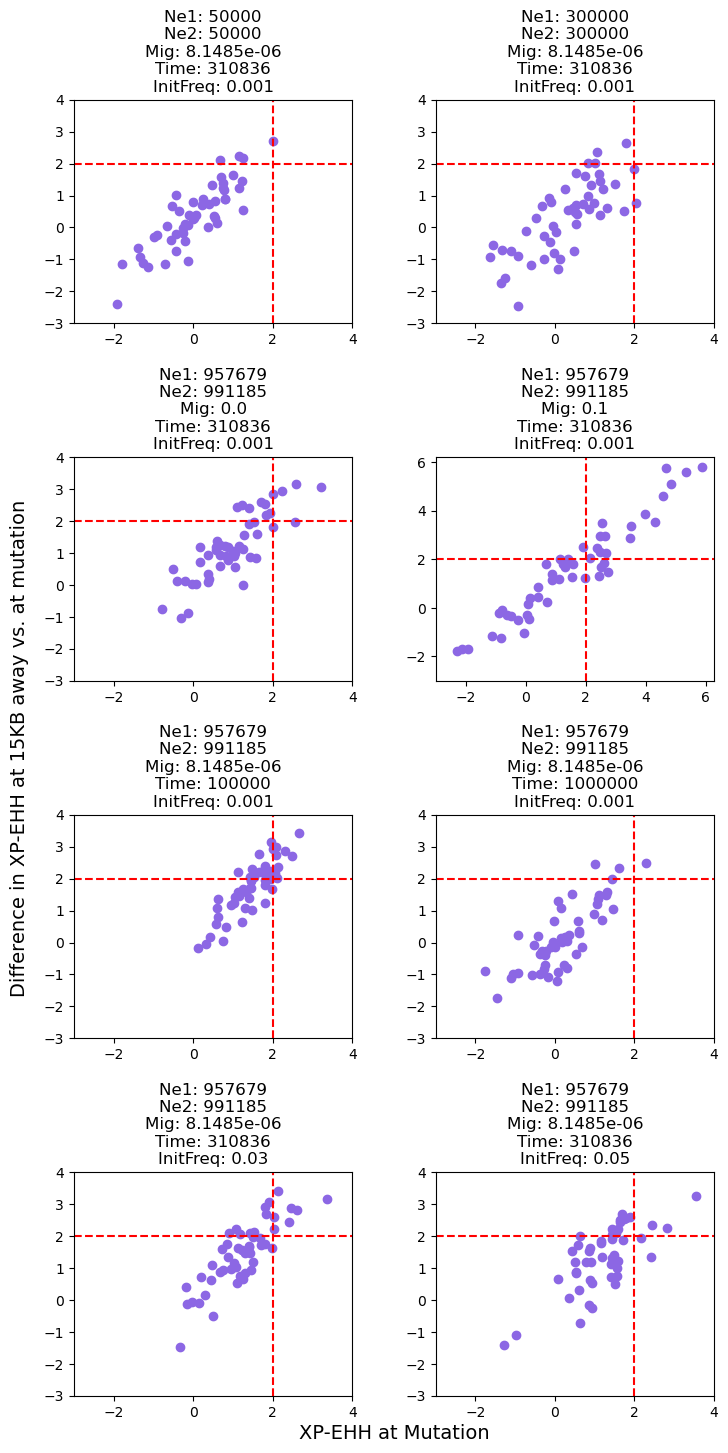

In [24]:
# define axis limits
x_min, x_max = -3, 4  # x-limits
y_min, y_max = -3, 4  # y-limits

# make a grid of subplots
fig, axs = plt.subplots(4, 2, figsize=(8,14.4))#figsize=(8, 18))

# flatten axes for iter
axs = axs.flatten()

# loop to create plots
for idx, i in enumerate([0,1,3,5,6,7,8,9]):#range(10):
    axs[idx].scatter(rep_results[i][0][:50], rep_results[i][1][:50], color='#8C67E4')
    # x y limits
    if idx != 3:
        axs[idx].set_xlim(x_min, x_max)
        axs[idx].set_ylim(y_min, y_max)
    else:
        axs[idx].set_xlim(left=x_min,right=None)
        axs[idx].set_ylim(bottom=y_min,top=None)
    # axs[i].set_title(f'Scatter {i+1}')
    # axs[i].set_title('\n'.join(map(str, reps[i])))
    axs[idx].set_title('\n'.join([''.join(i) for i in list(zip(['Ne1: ','Ne2: ', 'Mig: ', 'Time: ', 'InitFreq: '], map(str, reps[i])))]))
    #axs[idx].axvline(-2, color='red', linestyle='--')
    axs[idx].axvline(2, color='red', linestyle='--')
    #axs[idx].axhline(-2, color='red', linestyle='--')
    axs[idx].axhline(2, color='red', linestyle='--')

# layout tuning
plt.tight_layout()
plt.subplots_adjust(left=0.1, bottom=0.05, right=0.9, top=0.95, wspace=0.3, hspace=0.6)

# single x and y label fr all
fig.text(0.5, 0.02, 'XP-EHH at Mutation', ha='center', fontsize=14)  # x label outside bottom
fig.text(0.02, 0.5, 'Difference in XP-EHH at 15KB away vs. at mutation', va='center', rotation='vertical', fontsize=14)  # y label on left

# save as pdf
plt.savefig('./xpehh_scatterplots_grid_splitmod_reduced.pdf', format='pdf')

# show plot
plt.show()

# Tajima's D Plotting

In [15]:
reps

[[50000, 50000, 8.1485e-06, 310836, 0.001],
 [300000, 300000, 8.1485e-06, 310836, 0.001],
 [957679, 991185, 8.1485e-06, 310836, 0.001],
 [957679, 991185, 0.0, 310836, 0.001],
 [957679, 991185, 0.01, 310836, 0.001],
 [957679, 991185, 0.1, 310836, 0.001],
 [957679, 991185, 8.1485e-06, 100000, 0.001],
 [957679, 991185, 8.1485e-06, 1000000, 0.001],
 [957679, 991185, 8.1485e-06, 310836, 0.03],
 [957679, 991185, 8.1485e-06, 310836, 0.05]]

In [16]:
sfs_dir = "../comb_sims_splitmod/sfs/"
rep_results = []
for rep in reps:
    ne1 = rep[0]
    ne2 = rep[1]
    mig = rep[2]
    time_ = rep[3]
    startfreq = rep[4]
    nename = str(ne1).replace('.', '_')
    migname = str(mig).replace('.', '_')
    timename = str(time_).replace('.', '_')
    startfreqname = str(startfreq).replace('.', '_')

    # get the paths to the matching xpehh files
    rep_sfs_prefix = "-".join([nename,migname,timename,startfreqname])
    sfs_fns = [i for i in os.listdir(sfs_dir) if i.startswith(rep_sfs_prefix)]
    sfs_paths = [os.path.join(sfs_dir,i) for i in sfs_fns]

    # get the paths to the corresponding results files
    resfile_dir = os.path.join(*['../comb_sims_splitmod',nename,migname,timename,startfreqname])
    res_fns=[i.split('-')[-1].replace('.csv','.results.txt') for i in sfs_fns]
    resfile_paths = [os.path.join(resfile_dir,i) for i in res_fns]

    # get the mutation positions for each
    mut_positions = [int(find_position_of_mutation(i))+1 for i in resfile_paths]

    tajd_at_muts = []
    tajd_flanking_differences = []
    for idx, sfs_path in enumerate(sfs_paths):
        mut_pos = mut_positions[idx]
        lower_15k = mut_pos-15000
        upper_15k = mut_pos+15000

        sfs_results = pd.read_csv(sfs_path)
        relevant_rows = sfs_results[(sfs_results.START<=mut_pos)&(sfs_results.END>mut_pos)]
        tajd_mutpos = relevant_rows.TAJIMA_D.mean()

        relevant_rows = sfs_results[(sfs_results.START<=lower_15k)&(sfs_results.END>lower_15k)]
        tajd_lower = relevant_rows.TAJIMA_D.mean()

        relevant_rows = sfs_results[(sfs_results.START<=upper_15k)&(sfs_results.END>upper_15k)]
        tajd_upper = relevant_rows.TAJIMA_D.mean()

        tajd_flanking_difference = np.mean([tajd_lower, tajd_upper]) - tajd_mutpos

        tajd_at_muts.append(tajd_mutpos)
        tajd_flanking_differences.append(tajd_flanking_difference)
    rep_results.append([tajd_at_muts,tajd_flanking_differences])

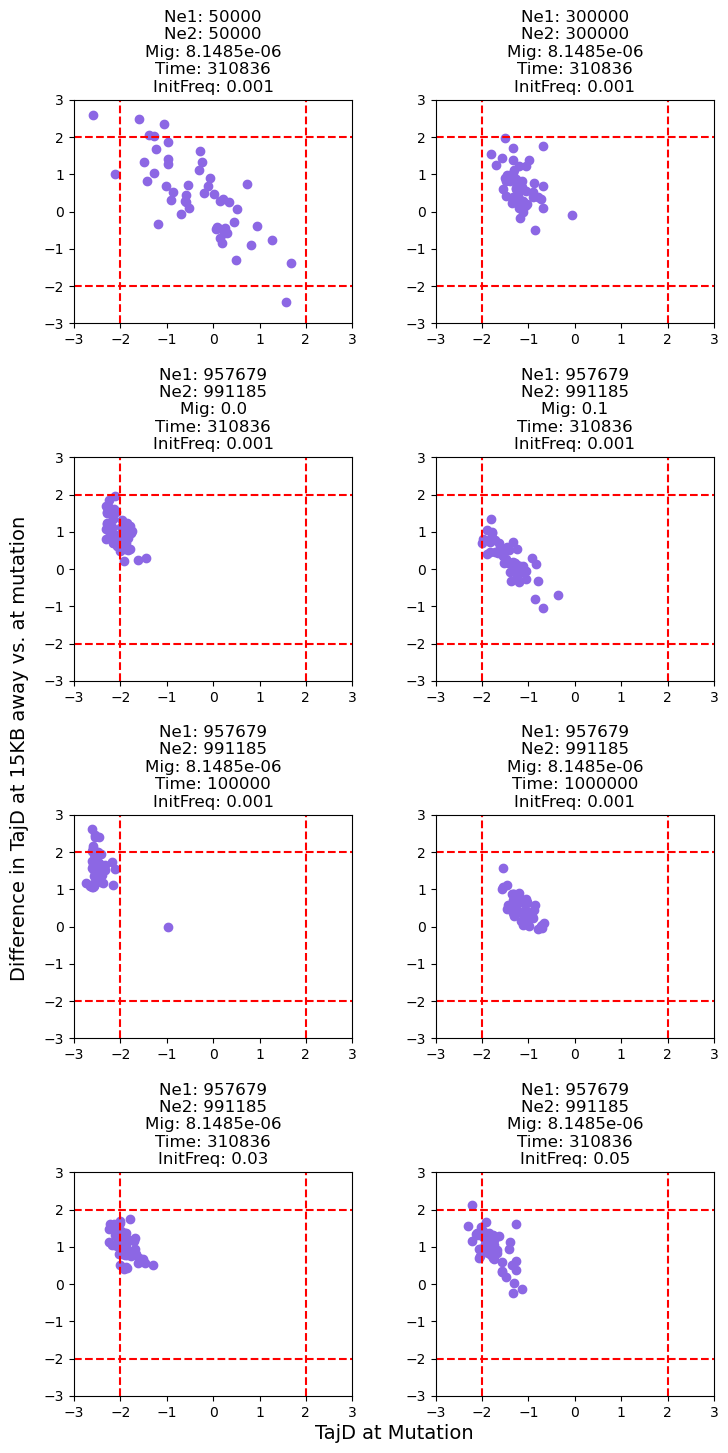

In [18]:
# define axis limits
x_min, x_max = -3, 3
y_min, y_max = -3, 3

# make a grid of subplots
fig, axs = plt.subplots(4, 2, figsize=(8,14.4))#figsize=(8, 18))

# flatten axes for iter
axs = axs.flatten()

# loop to create plots
for idx, i in enumerate([0,1,3,5,6,7,8,9]):#range(10):
    axs[idx].scatter(rep_results[i][0][:50], rep_results[i][1][:50], color='#8C67E4')
    # Set consistent x and y limits
    axs[idx].set_xlim(x_min, x_max)
    axs[idx].set_ylim(y_min, y_max)
    # axs[i].set_title(f'Scatter {i+1}')
    # axs[i].set_title('\n'.join(map(str, reps[i])))
    axs[idx].set_title('\n'.join([''.join(i) for i in list(zip(['Ne1: ','Ne2: ', 'Mig: ', 'Time: ', 'InitFreq: '], map(str, reps[i])))]))
    axs[idx].axvline(-2, color='red', linestyle='--')
    #axs[idx].axvline(2, color='red', linestyle='--')
    #axs[idx].axhline(-2, color='red', linestyle='--')
    axs[idx].axhline(2, color='red', linestyle='--')

# layout tuning
plt.tight_layout()
plt.subplots_adjust(left=0.1, bottom=0.05, right=0.9, top=0.95, wspace=0.3, hspace=0.6)

# single x and y label fr all
fig.text(0.5, 0.02, 'TajD at Mutation', ha='center', fontsize=14)  # X-label placed outside the bottom
fig.text(0.02, 0.5, 'Difference in TajD at 15KB away vs. at mutation', va='center', rotation='vertical', fontsize=14)  # Y-label placed outside the left

# save as pdf
plt.savefig('./tajd_scatterplots_grid_splitmod_reduced.pdf', format='pdf')

# show plot
plt.show()

# Inset showing one sampled trajectory

In [151]:
all_sfs_fns = os.listdir('../comb_sims_splitmod/sfs')

In [152]:
selected_rep_fns = [i for i in all_sfs_fns if i.startswith('957679-8_1485e-06-310836-0_001')]

In [187]:
selected_rep_fns[39]

'957679-8_1485e-06-310836-0_001-70.csv'

In [192]:
tajd_line = pd.read_csv('../comb_sims_splitmod/sfs/{}'.format(selected_rep_fns[39]))

In [193]:
mutpos = int(find_position_of_mutation('../comb_sims_splitmod/957679/8_1485e-06/310836/0_001/70.results.txt')) # 15

flankup = mutpos+15000
flankdown = mutpos-15000

In [194]:
xpos = np.linspace(flankdown,flankup,101)

In [195]:
mutpos

24518

In [196]:
def get_val_at_pos(pos,df):
    relevant_rows = df[(df.START<=pos)&(df.END>pos)]
    tajd_mutpos = relevant_rows.TAJIMA_D.mean()
    return(tajd_mutpos)

In [197]:
y_vals = [get_val_at_pos(i,tajd_line) for i in xpos]

In [198]:
x = np.linspace(-15000,15000,101)

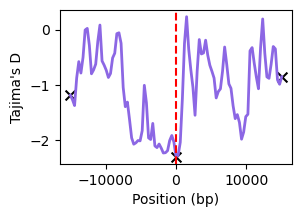

In [200]:
plt.figure(figsize=(3, 2))

# plot each separately
for i, y_i in enumerate([y_vals]):
    plt.plot(x, 
             y_i, 
             #marker='o',
             color='#8C67E4',
             linewidth=2, 
             label=f'Line {i}')
plt.scatter(0, y_vals[50], marker='x', color='black', s=50)
plt.scatter(-15000, y_vals[0], marker='x', color='black', s=50)
plt.scatter(15000, y_vals[-1], marker='x', color='black', s=50)
plt.axvline(0, color='red', linestyle='--')
#plt.axvline(, color='red', linestyle='--')
#plt.axvline(flankdown, color='red', linestyle='--')
#  axes
plt.xlabel("Position (bp)")
plt.ylabel("Tajima's D")

# save as pdf
plt.savefig('./inset_line.pdf', format='pdf')

# display
plt.show()